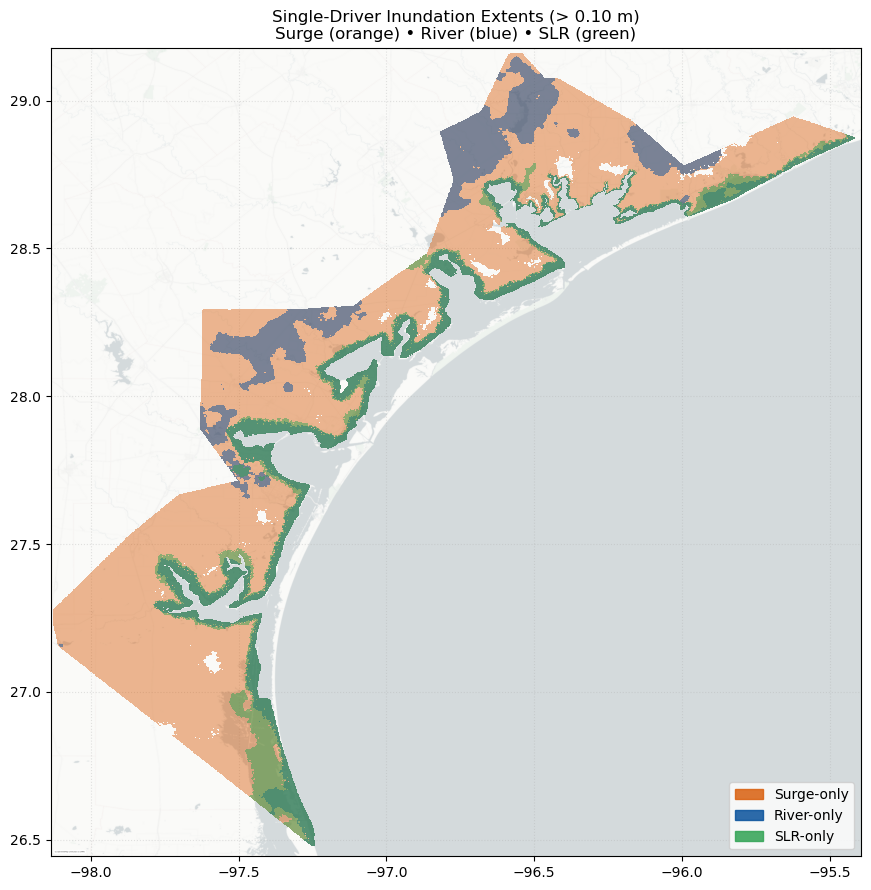

In [2]:
import rasterio
from rasterio.warp import reproject, Resampling, transform_bounds
from rasterio.transform import from_origin
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import contextily as ctx
import math

# ---------- USER INPUTS ----------
# Single-driver depth rasters (meters)
r_surge = r"D:\Phd Research\Final_Raster\Inundation_only_for_Surge_100yr.tif"
r_slr   = r"D:\Phd Research\Final_Raster\Inundation_only_for_SLR.tif"
r_river = r"D:\Phd Research\Final_Raster\100yr_Q_flood_only.tif"

THRESH = 0.10         # depth threshold to define inundation
TARGET_CRS = "EPSG:4326"     # plot grid CRS (lon/lat)
TARGET_RES = 0.0005          # degrees/pixel (~45–55 m near TX); increase if memory is an issue
BASEMAP_ZOOM = 11            # basemap zoom level
# ---------------------------------

def read_wet_mask(path, thresh=THRESH):
    """Return (0/1 inundation mask, minimal profile)."""
    with rasterio.open(path) as src:
        arr = src.read(1, masked=True)  # MaskedArray uses nodata
        valid = (~arr.mask) & np.isfinite(arr)
        wet = np.zeros(arr.shape, dtype="uint8")
        wet[valid & (arr > thresh)] = 1
        prof = {"crs": src.crs, "transform": src.transform,
                "width": src.width, "height": src.height}
    return wet, prof

def union_bounds_in_target(profiles, target_crs):
    xs_min, ys_min, xs_max, ys_max = [], [], [], []
    for p in profiles:
        h, w = p["height"], p["width"]
        left, bottom, right, top = rasterio.transform.array_bounds(h, w, p["transform"])
        l, b, r, t = transform_bounds(p["crs"], target_crs, left, bottom, right, top, densify_pts=21)
        xs_min.append(l); ys_min.append(b); xs_max.append(r); ys_max.append(t)
    return min(xs_min), min(ys_min), max(xs_max), max(ys_max)

def make_dst_geo(left, bottom, right, top, res):
    width  = int(math.ceil((right  - left) / res))
    height = int(math.ceil((top    - bottom) / res))
    transform = from_origin(left, top, res, res)
    return transform, width, height

def reproject_mask_uint8(src_mask, src_prof, dst_transform, dst_crs, dst_w, dst_h):
    dst = np.zeros((dst_h, dst_w), dtype="uint8")
    reproject(
        source=src_mask,
        destination=dst,
        src_transform=src_prof["transform"], src_crs=src_prof["crs"],
        dst_transform=dst_transform,      dst_crs=dst_crs,
        resampling=Resampling.nearest
    )
    return dst

# --- 1) Build wet masks for each single-driver raster ---
m_surge, p_surge = read_wet_mask(r_surge)  # SURGE-ONLY
m_river, p_river = read_wet_mask(r_river)  # RIVER-ONLY
m_slr,   p_slr   = read_wet_mask(r_slr)    # SLR-ONLY

# --- 2) Common plot grid in TARGET_CRS covering all datasets ---
left, bottom, right, top = union_bounds_in_target([p_surge, p_river, p_slr], TARGET_CRS)
dst_transform, dst_w, dst_h = make_dst_geo(left, bottom, right, top, TARGET_RES)
extent = (left, right, bottom, top)

# --- 3) Reproject masks to the common grid ---
dst_surge = reproject_mask_uint8(m_surge, p_surge, dst_transform, TARGET_CRS, dst_w, dst_h)
dst_river = reproject_mask_uint8(m_river, p_river, dst_transform, TARGET_CRS, dst_w, dst_h)
dst_slr   = reproject_mask_uint8(m_slr,   p_slr,   dst_transform, TARGET_CRS, dst_w, dst_h)

# --- 4) Plot (order: Surge -> River -> SLR) ---
fig, ax = plt.subplots(figsize=(10, 9))

# Basemap underneath
ax.set_xlim(left, right); ax.set_ylim(bottom, top)
ctx.add_basemap(ax, crs=TARGET_CRS, source=ctx.providers.CartoDB.PositronNoLabels,
                zoom=BASEMAP_ZOOM, attribution_size=0, zorder=1)

# Transparent binary colormaps (0=transparent, 1=colored)
cmap_surge = ListedColormap([(0,0,0,0), (217/255, 95/255, 14/255, 0.45)])   # orange
cmap_river = ListedColormap([(0,0,0,0), (  8/255, 81/255,156/255, 0.50)])   # blue
cmap_slr   = ListedColormap([(0,0,0,0), ( 49/255,163/255, 84/255, 0.50)])   # green

# Draw in requested order so colors remain visible
ax.imshow(dst_surge, extent=extent, origin='upper', cmap=cmap_surge,
          interpolation='nearest', zorder=3)
ax.imshow(dst_river, extent=extent, origin='upper', cmap=cmap_river,
          interpolation='nearest', zorder=4)
ax.imshow(dst_slr,   extent=extent, origin='upper', cmap=cmap_slr,
          interpolation='nearest', zorder=5)

# Labels / legend
ax.set_title(f"Single-Driver Inundation Extents (> {THRESH:.2f} m)\nSurge (orange) • River (blue) • SLR (green)")
ax.set_aspect('equal'); ax.grid(True, linestyle=':', alpha=0.35)

legend_patches = [
    mpatches.Patch(color=(217/255, 95/255, 14/255, 0.85), label='Surge-only'),
    mpatches.Patch(color=(  8/255, 81/255,156/255, 0.85), label='River-only'),
    mpatches.Patch(color=( 49/255,163/255, 84/255, 0.85), label='SLR-only'),
]
ax.legend(handles=legend_patches, loc='lower right', frameon=True)

plt.tight_layout()
plt.show()


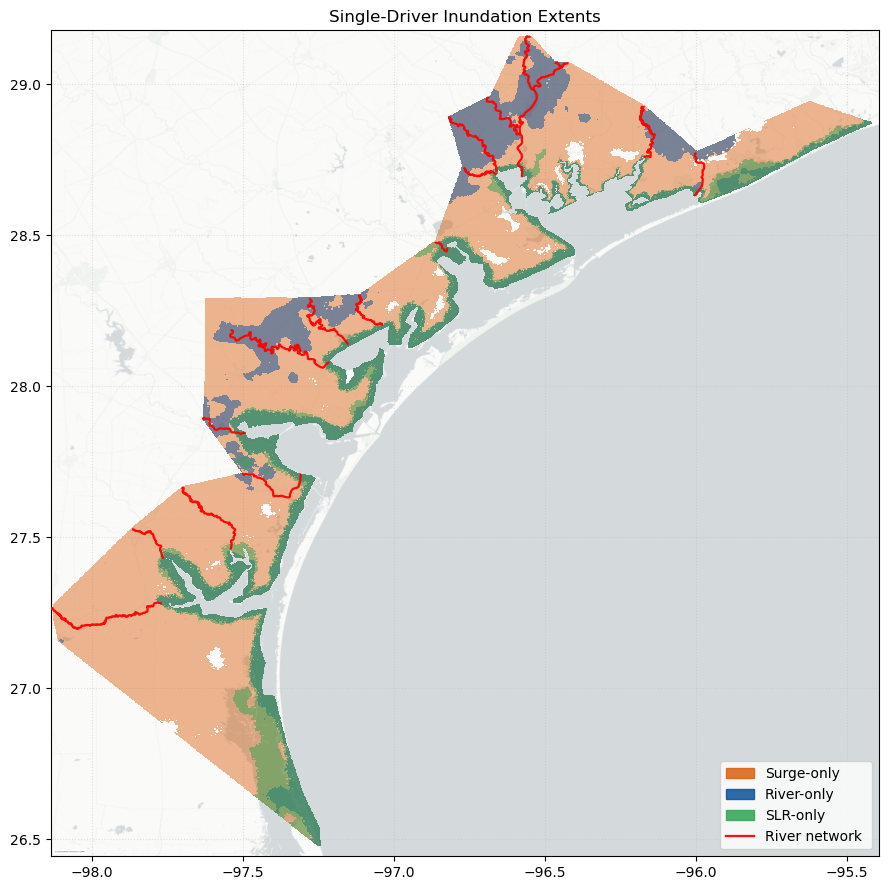

In [4]:
import os, zipfile
import geopandas as gpd
from shapely.geometry import box
from matplotlib.lines import Line2D

import rasterio
from rasterio.warp import reproject, Resampling, transform_bounds
from rasterio.transform import from_origin
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import contextily as ctx
import math

# ---------- USER INPUTS ----------
# Single-driver depth rasters (meters)
r_surge = r"D:\Phd Research\Final_Raster\Inundation_only_for_Surge_100yr.tif"
r_slr   = r"D:\Phd Research\Final_Raster\Inundation_only_for_SLR.tif"
r_river = r"D:\Phd Research\Final_Raster\100yr_Q_flood_only.tif"

# River network (zipped shapefile, UTM)
river_zip   = r"D:\Phd Research\1D HD Model\Shape file\River_Network_final.zip"
river_unzip = r"D:\Phd Research\1D HD Model\Shape file\unzipped_rivers"  # temp folder

THRESH = 0.10                  # inundation threshold
TARGET_CRS = "EPSG:4326"       # map CRS (lon/lat)
TARGET_RES = 0.0005            # deg/pixel (~45–55 m in TX)
BASEMAP_ZOOM = 11              # basemap zoom level

# Rivers style
RIVER_COLOR = (1, 0, 0, 0.95)  # red
RIVER_LW    = 1.6
CLIP_RIVERS_TO_EXTENT = True   # speed-up / clarity
# ---------------------------------

def read_wet_mask(path, thresh=THRESH):
    """Return (0/1 inundation mask, minimal profile)."""
    with rasterio.open(path) as src:
        arr = src.read(1, masked=True)  # MaskedArray uses nodata
        valid = (~arr.mask) & np.isfinite(arr)
        wet = np.zeros(arr.shape, dtype="uint8")
        wet[valid & (arr > thresh)] = 1
        prof = {"crs": src.crs, "transform": src.transform,
                "width": src.width, "height": src.height}
    return wet, prof

def union_bounds_in_target(profiles, target_crs):
    xs_min, ys_min, xs_max, ys_max = [], [], [], []
    for p in profiles:
        h, w = p["height"], p["width"]
        left, bottom, right, top = rasterio.transform.array_bounds(h, w, p["transform"])
        l, b, r, t = transform_bounds(p["crs"], target_crs, left, bottom, right, top, densify_pts=21)
        xs_min.append(l); ys_min.append(b); xs_max.append(r); ys_max.append(t)
    return min(xs_min), min(ys_min), max(xs_max), max(ys_max)

def make_dst_geo(left, bottom, right, top, res):
    width  = int(math.ceil((right  - left) / res))
    height = int(math.ceil((top    - bottom) / res))
    transform = from_origin(left, top, res, res)
    return transform, width, height

def reproject_mask_uint8(src_mask, src_prof, dst_transform, dst_crs, dst_w, dst_h):
    dst = np.zeros((dst_h, dst_w), dtype="uint8")
    reproject(
        source=src_mask,
        destination=dst,
        src_transform=src_prof["transform"], src_crs=src_prof["crs"],
        dst_transform=dst_transform,      dst_crs=dst_crs,
        resampling=Resampling.nearest
    )
    return dst

def read_rivers(zip_path, out_dir, target_crs):
    """Unzip if needed, read shapefile, reproject to target CRS."""
    if not os.path.isdir(out_dir) or not any(f.endswith(".shp") for f in os.listdir(out_dir)):
        os.makedirs(out_dir, exist_ok=True)
        with zipfile.ZipFile(zip_path, "r") as z:
            z.extractall(out_dir)
    shp_files = [os.path.join(out_dir, f) for f in os.listdir(out_dir) if f.endswith(".shp")]
    if not shp_files:
        raise FileNotFoundError("No .shp found after unzipping the river network.")
    gdf = gpd.read_file(shp_files[0])
    if gdf.crs is None:
        raise ValueError("River shapefile has no CRS defined. Set its CRS (UTM) before plotting.")
    return gdf.to_crs(target_crs)

# --- 1) Build wet masks for each single-driver raster ---
m_surge, p_surge = read_wet_mask(r_surge)
m_river, p_river = read_wet_mask(r_river)
m_slr,   p_slr   = read_wet_mask(r_slr)

# --- 2) Common plot grid in TARGET_CRS covering all datasets ---
left, bottom, right, top = union_bounds_in_target([p_surge, p_river, p_slr], TARGET_CRS)
dst_transform, dst_w, dst_h = make_dst_geo(left, bottom, right, top, TARGET_RES)
extent = (left, right, bottom, top)

# --- 3) Reproject masks to the common grid ---
dst_surge = reproject_mask_uint8(m_surge, p_surge, dst_transform, TARGET_CRS, dst_w, dst_h)
dst_river = reproject_mask_uint8(m_river, p_river, dst_transform, TARGET_CRS, dst_w, dst_h)
dst_slr   = reproject_mask_uint8(m_slr,   p_slr,   dst_transform, TARGET_CRS, dst_w, dst_h)

# --- 4) Read / reproject rivers to TARGET_CRS, clip to extent if desired ---
gdf_rivers = read_rivers(river_zip, river_unzip, TARGET_CRS)
if CLIP_RIVERS_TO_EXTENT:
    gdf_rivers = gdf_rivers.clip(box(*extent))

# --- 5) Plot (order: Surge -> River -> SLR), rivers on TOP ---
fig, ax = plt.subplots(figsize=(10, 9))

# Basemap underneath
ax.set_xlim(left, right); ax.set_ylim(bottom, top)
ctx.add_basemap(ax, crs=TARGET_CRS, source=ctx.providers.CartoDB.PositronNoLabels,
                zoom=BASEMAP_ZOOM, attribution_size=0, zorder=1)

# Transparent binary colormaps (0=transparent, 1=colored)
cmap_surge = ListedColormap([(0,0,0,0), (217/255, 95/255, 14/255, 0.45)])   # orange
cmap_river = ListedColormap([(0,0,0,0), (  8/255, 81/255,156/255, 0.50)])   # blue
cmap_slr   = ListedColormap([(0,0,0,0), ( 49/255,163/255, 84/255, 0.50)])   # green

# Draw rasters in requested order
ax.imshow(dst_surge, extent=extent, origin='upper', cmap=cmap_surge, interpolation='nearest', zorder=3)
ax.imshow(dst_river, extent=extent, origin='upper', cmap=cmap_river, interpolation='nearest', zorder=4)
ax.imshow(dst_slr,   extent=extent, origin='upper', cmap=cmap_slr,   interpolation='nearest', zorder=5)

# Rivers ON TOP (red)
gdf_rivers.plot(ax=ax, color=RIVER_COLOR, linewidth=RIVER_LW, zorder=7)

# Labels / legend
ax.set_title(f"Single-Driver Inundation Extents")
ax.set_aspect('equal'); ax.grid(True, linestyle=':', alpha=0.35)

legend_patches = [
    mpatches.Patch(color=(217/255, 95/255, 14/255, 0.85), label='Surge-only'),
    mpatches.Patch(color=(  8/255, 81/255,156/255, 0.85), label='River-only'),
    mpatches.Patch(color=( 49/255,163/255, 84/255, 0.85), label='SLR-only'),
    Line2D([], [], color=RIVER_COLOR, linewidth=RIVER_LW, label='River network '),
]
ax.legend(handles=legend_patches, loc='lower right', frameon=True)

plt.tight_layout()
plt.show()
